<a href="https://colab.research.google.com/github/VSGopiChanduNeelam/CT_TASK_06_POST_PROCESSING/blob/main/bm3d_denoising_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget -q https://www.kaggle.com/api/v1/datasets/download/paultimothymooney/chest-xray-pneumonia -O chest_xray.zip
!unzip -q chest_xray.zip

In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

folder = "chest_xray/test/NORMAL"

files = os.listdir(folder)

image_name = random.choice(files)

image_path = os.path.join(folder, image_name)

print("Selected:", image_path)

Selected: chest_xray/test/NORMAL/NORMAL2-IM-0096-0001.jpeg


In [ ]:
clean = cv2.imread(image_path,cv2.IMREAD_GRAYSCALE)
print(clean.shape)

(1979, 2517)


In [ ]:
clean = cv2.resize(clean,(256, 256))
clean = clean.astype(np.float32) / 255.0

In [ ]:
sigma = 0.10
noise = np.random.normal(0,sigma,clean.shape)
noisy = clean + noise
noisy = np.clip( noisy,0,1)

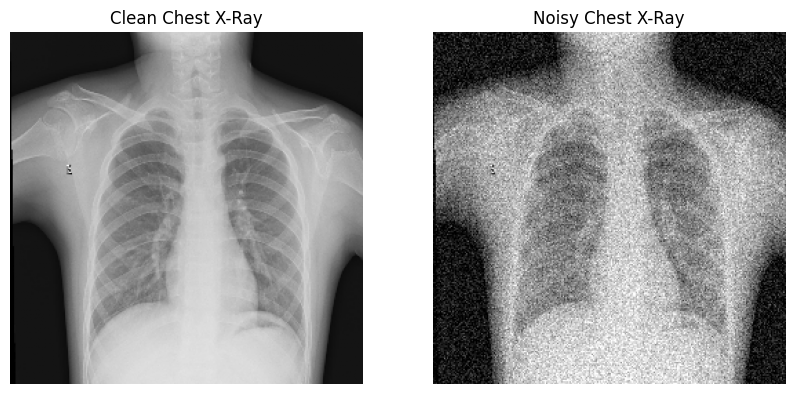

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(clean, cmap="gray")
plt.title("Clean Chest X-Ray")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(noisy, cmap="gray")
plt.title("Noisy Chest X-Ray")
plt.axis("off")

plt.show()

In [ ]:
from bm3d import bm3d, BM3DStages

denoised = bm3d(noisy,sigma_psd=sigma,stage_arg=BM3DStages.ALL_STAGES)

denoised = np.clip( denoised,0,1)

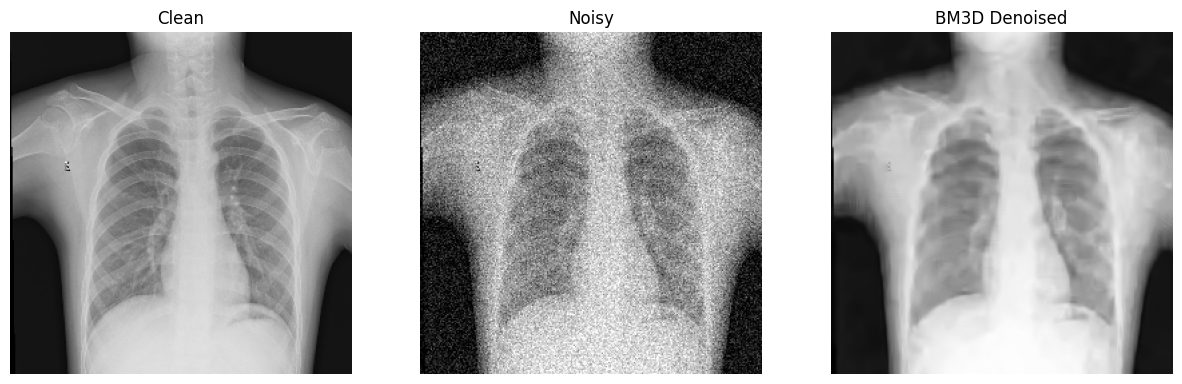

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(clean, cmap="gray")
plt.title("Clean")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy, cmap="gray")
plt.title("Noisy")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(denoised, cmap="gray")
plt.title("BM3D Denoised")
plt.axis("off")

plt.show()

In [ ]:
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

psnr_noisy = peak_signal_noise_ratio(clean,noisy,data_range=1.0)

ssim_noisy = structural_similarity(clean,noisy,data_range=1.0)

psnr_bm3d = peak_signal_noise_ratio(clean,denoised,data_range=1.0)

ssim_bm3d = structural_similarity(clean,denoised,data_range=1.0)

print("Noisy")
print("PSNR:", psnr_noisy)
print("SSIM:", ssim_noisy)

print("\nBM3D")
print("PSNR:", psnr_bm3d)
print("SSIM:", ssim_bm3d)

Noisy
PSNR: 20.40717513727527
SSIM: 0.24922745357154216

BM3D
PSNR: 32.58965453822205
SSIM: 0.8656446700484752


In [ ]:
os.makedirs("results", exist_ok=True)

cv2.imwrite( "results/clean.png",(clean * 255).astype(np.uint8))

cv2.imwrite("results/noisy.png",(noisy * 255).astype(np.uint8))

cv2.imwrite("results/bm3d.png",(denoised * 255).astype(np.uint8))

True